<a href="https://colab.research.google.com/github/Morax19/DL_UCV/blob/Tarea2/Tarea2/DL_Tarea2_DanielHernandez_27795163.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tarea 2**: CNN & UNETs<br>
Tópicos en Inteligencia Artificial: Redes Neuronales Profundas<br>
Escuela de Computación, Facultad de Ciencias - UCV<br>
Semestre 1-2025<br>

# **Tarea 2 : Arquitecturas modernas de Redes Neuronales Profundas (CNN & UNETs)**

**Profesor**: Fernando Crema García<br>
**Autor**: Daniel Hernández<br>

## **Parte I: Introducción**

### **I-A.1**. Resolución de los notebooks del libro UDL:
A lo largo de esta sección se dejarán los enlaces a los notebooks resueltos.

*   **Notebook 10.1 - 1D convolution**
<br>Link al notebook resuelto: [DL_DanielHernandez_10_1_1D_Convolution](https://colab.research.google.com/drive/1QKjaiRpVdNR_cXpGxIo58vvThS0-RmpO?usp=sharing)

*   **Notebook 10.2 - Convolution for MNIST-1D**
<br>Link al notebook resuelto: [DL_DanielHernandez_10_2_Convolution_for_MNIST_1D](https://colab.research.google.com/drive/1vJO7YMid7nDf2Zyr8_5z61RKyy22qmaa?usp=sharing)

*   **Notebook 10.3 - 2D convolution**
<br>Link al notebook resuelto: [DL_DanielHernandez_10_3_2D_Convolution](https://colab.research.google.com/drive/17KUbHlq1HXdvwrde5fZdXCeauwWzx1Gi?usp=sharing)

*   **Notebook 10.4 - Downsampling & upsampling**
<br>Link al notebook resuelto: [DL_DanielHernandez_10_4_Downsampling_and_Upsampling](https://colab.research.google.com/drive/1msu2WHOFs204CNwzgRL3jUcbKEy9Ck0d?usp=sharing)

*   **Notebook 10.5 - Convolution for MNIST**
<br>Link al notebook resuelto: [DL_DanielHernandez_10_5_Convolution_For_MNIST](https://colab.research.google.com/drive/1F3v7wEOwdGUSrCvy8Tr1tEVDwDLx32dZ?usp=sharing)

### **I-A.2**. Experimento Final
En esta sección, se hará uso del código hecho en los notebooks anteriores, específicamente las funciones para el max pooling, mean pooling y convolution 2D. La idea original consistía de definir una red neuronal utilizando la estructura de PyTorch pero en lugar de usar los métodos definidos en la clase nn, usar los propios, es decir, utilizar **conv_numpy_4()** en lugar de **nn.Conv2d()**, **maxpool()** en lugar de **nn.MaxPool2d()** durante el entrenamiento y prueba, sin embargo, al realizar pruebas con este enfoque híbrido el tiempo de entrenamiento era exageradamente alto, es por ello que el experimento va a consistir en comparar los resultados obtenidos por los métodos de PyTorch y los de las implementaciones propias.

Como primer paso, se configurará el entorno para descargar el dataset de Kaggle, para ello fue necesario definir 2 variables de entorno en la sección Secrets de Google Colab que corresponden al nombre de usuario de Kaggle y la Key correspondiente para el uso de su API.

In [ ]:
import os
import torch
import zipfile
import kagglehub
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import userdata
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split

In [ ]:
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

KAGGLE_USER = userdata.get('KAGGLE_USER')
KAGGLE_KEY = userdata.get('KAGGLE_KEY')

if not KAGGLE_USER or not KAGGLE_KEY:
    print("Error: KAGGLE_USERNAME and/or KAGGLE_KEY environment variables are not set.")
    print("Please set them in Colab Secrets before running this script.")
else:
    kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')
    with open(kaggle_json_path, 'w') as f:
        f.write(f'{{"username":"{KAGGLE_USER}","key":"{KAGGLE_KEY}"}}')
    print(f"kaggle.json created at {kaggle_json_path}")
    !chmod 600 {kaggle_json_path}

# Download latest version
kaggle_data = kagglehub.dataset_download("ashfakyeafi/cat-dog-images-for-classification")

print("Path to dataset files:", kaggle_data)

kaggle.json created at /root/.kaggle/kaggle.json
Path to dataset files: /root/.cache/kagglehub/datasets/ashfakyeafi/cat-dog-images-for-classification/versions/2


Instancia del conjunto de datos, consiste de 25 mil imágenes de perros y gatos distribuidas de forma balanceada, originalmente las dimensiones de las mismas no son iguales entre sí, por motivos del experimento vamos a redimensionarlas a 128 píxeles de alto por 128 píxeles de ancho.

In [ ]:
data_base_path = kaggle_data
csv_file = "cat_dog.csv"
img_path = "cat_dog"

# Clase para la transformación de los datos.
class CatDogDataset(Dataset):
    def __init__(self, csv_file, img_path, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_path = img_path
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx, 0]
        label = self.data.iloc[idx, 1]

        img_full_path = os.path.join(self.img_path, img_name)

        image = Image.open(img_full_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# Variable donde se van a almcenar las imágenes.
dataset = CatDogDataset(
    csv_file=os.path.join(data_base_path, csv_file),
    img_path=os.path.join(data_base_path, img_path),
    transform=transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
  ])
)

Configurando de los parámetros para el entrenamiento y prueba del modelo, se usará una distribución de 80% de datos para el entrenamiento y el resto para prueba.

In [ ]:
# Batch para entrenamiento y prueba
batch_size_train = 16
batch_size_test = 32

# Distribución de 70 - 30 para los datos
train_size = int(0.7 * len(dataset))
validate_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - validate_size
train_dataset, validate_dataset, test_dataset = random_split(dataset, [train_size, validate_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
validate_loader = DataLoader(validate_dataset, batch_size=batch_size_test, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size_test, shuffle=False)

Las siguientes celdas de código muestran los métodos definidos en los notebooks anteriormente mencionados:

In [ ]:
# Max pooling (Notebook 10.4)
def maxpool(x_in, dim):
  x_copy = to_numpy(x_in)
  x_out = np.zeros(( int(np.floor(x_copy.shape[0]/dim)), int(np.floor(x_copy.shape[1]/dim)) ))

  for i in range(x_out.shape[0]):
    for j in range(x_out.shape[1]):
      x_out[i,j] = np.max(x_copy[i * dim:i * dim+dim, j * dim:j * dim + dim])

  return to_tensor(x_out)

In [ ]:
# Mean pooling (Notebook 10.4)
def meanpool(x_in, dim):
  x_copy = to_numpy(x_in)
  x_out = np.zeros(( int(np.floor(x_copy.shape[0]/dim)), int(np.floor(x_copy.shape[1]/dim)) ))

  for i in range(x_out.shape[0]):
    for j in range(x_out.shape[1]):
      x_out[i,j] = np.mean(x_copy[i * dim:i * dim+dim, j * dim:j * dim + dim])

  return to_tensor(x_out)

In [ ]:
#2D Convolution (Notebook 10.3)
def conv_numpy_4(image_og, weights, stride=1, pad=1):
  image = to_numpy(image_og)
  # Perform zero padding
  if pad != 0:
      image = np.pad(image, ((0, 0), (0 ,0), (pad, pad), (pad, pad)),'constant')

  # Get sizes of image array and kernel weights
  batchSize,  channelsIn, imageHeightIn, imageWidthIn = image.shape
  channelsOut, channelsIn, kernelHeight, kernelWidth = weights.shape

  # Get size of output arrays
  imageHeightOut = np.floor(1 + (imageHeightIn - kernelHeight) / stride).astype(int)
  imageWidthOut = np.floor(1 + (imageWidthIn - kernelWidth) / stride).astype(int)

  # Create output
  out = np.zeros((batchSize, channelsOut, imageHeightOut, imageWidthOut), dtype=np.float32)

  for c_batch in range(batchSize):
    for c_y in range(imageHeightOut):
      for c_x in range(imageWidthOut):
        for c_channel_out in range(channelsOut):
          for c_channel_in in range(channelsIn):
            for c_kernel_y in range(kernelHeight):
              for c_kernel_x in range(kernelWidth):
                  this_pixel_value = image[c_batch, c_channel_in, c_y * stride + c_kernel_y, c_x * stride + c_kernel_x]
                  this_weight = weights[c_channel_out, c_channel_in, c_kernel_y, c_kernel_x]

                  out[c_batch, c_channel_out, c_y, c_x] += this_pixel_value * this_weight

  return to_tensor(out)

Cabe destacar que se modificaron para poder trabajar con tensores, para ello fue necesario definir los métodos **to_numpy()** y **to_tensor()**.

In [ ]:
# Convert tensor to numpy array
def to_numpy(data):
  if isinstance(data, np.ndarray):
    return data
  elif isinstance(data, torch.Tensor):
    if data.requires_grad:
        return data.detach().cpu().numpy()
    else:
        return data.cpu().numpy()
  else:
    raise TypeError(f"Unsupported data type for conversion to NumPy: {type(data)}. "
                      "Expected torch.Tensor or np.ndarray.")

In [ ]:
# Convert numpy array to tensor
def to_tensor(data, device='cpu', dtype=torch.float32):
  if isinstance(data, torch.Tensor):
    return data.to(device=device, dtype=dtype)
  elif isinstance(data, np.ndarray):
    tensor = torch.from_numpy(data).to(dtype=dtype).to(device)
    return tensor
  else:
    raise TypeError(f"Unsupported data type for conversion to Tensor: {type(data)}. "
                      "Expected np.ndarray or torch.Tensor.")

Para lograr que las funciones definidas en los notebooks tuviesen un comportamiento similar a las funciones implementadas en PyTorch, se definieron: **maxpool_channels()**, **meanpool_channels()**.

Originalmente, las funciones para el Max Pooling y Mean Pooling se aplican a 1 solo canal de la imagen de entrada, estas funciones se encargan de recibir dicha imagen y aplicar la correspondiente operación a cada canal de la misma.

In [ ]:
def maxpool_channels(tensor_in, pool_dim):
  if tensor_in.ndim == 4: # Handle batch dimension
      batch_size = tensor_in.shape[0]
      pooled_batch = []
      for i in range(batch_size):
          # Process each image in the batch (shape C, H, W)
          single_image = tensor_in[i, :, :, :]
          pooled_image = maxpool_channels(single_image, pool_dim) # Recursively call for a single image
          pooled_batch.append(pooled_image)
      return torch.stack(pooled_batch, dim=0) # Stack the pooled images back into a batch

  elif tensor_in.ndim == 3: # Handle single image (C, H, W)
      channels = tensor_in.shape[0]
      pooled_channels = []

      for i in range(channels):
        # Select a single channel (shape H, W)
        single_channel = tensor_in[i, :, :]
        # Apply the custom maxpool function to the single channel (maxpool expects 2D)
        pooled_channel = maxpool(single_channel, pool_dim)
        pooled_channels.append(pooled_channel)

      # Stack the pooled channels back together along the channel dimension
      pooled_tensor = torch.stack(pooled_channels, dim=0)
      return pooled_tensor

  else:
      raise ValueError(f"Input tensor must have 3 or 4 dimensions (C, H, W) or (N, C, H, W), but got {tensor_in.ndim} dimensions.")

In [ ]:
def meanpool_channels(tensor_in, pool_dim):
  if tensor_in.ndim == 4: # Handle batch dimension
      batch_size = tensor_in.shape[0]
      pooled_batch = []
      for i in range(batch_size):
          # Process each image in the batch (shape C, H, W)
          single_image = tensor_in[i, :, :, :]
          pooled_image = meanpool_channels(single_image, pool_dim) # Recursively call for a single image
          pooled_batch.append(pooled_image)
      return torch.stack(pooled_batch, dim=0) # Stack the pooled images back into a batch

  elif tensor_in.ndim == 3: # Handle single image (C, H, W)
      channels = tensor_in.shape[0]
      pooled_channels = []

      for i in range(channels):
        # Select a single channel (shape H, W)
        single_channel = tensor_in[i, :, :]
        # Apply the custom maxpool function to the single channel (maxpool expects 2D)
        pooled_channel = meanpool(single_channel, pool_dim)
        pooled_channels.append(pooled_channel)

      # Stack the pooled channels back together along the channel dimension
      pooled_tensor = torch.stack(pooled_channels, dim=0)
      return pooled_tensor

  else:
      raise ValueError(f"Input tensor must have 3 or 4 dimensions (C, H, W) or (N, C, H, W), but got {tensor_in.ndim} dimensions.")

Para realizar la comparativa, vamos a definir una función que nos permita imprimir una imagen dada, la idea principal es tomar una imagen durante el entrenamiento del modelo y mostrar como esta va cambiando al aplicar las operaciones definidas en la red usando ambas funciones disponibles, para ello se definen las funciones siguientes:

In [ ]:
# Imprime una imagen dado un tensor
def display_tensor_image(tensor_image, title="Image"):
  # If the tensor has a batch dimension (N, C, H, W), select the first image (C, H, W)
  if tensor_image.ndim == 4:
      image = tensor_image[0]
  else:
      image = tensor_image

  image = image.detach().cpu().numpy()

  # Transpose from (C, H, W) to (H, W, C) for displaying with matplotlib
  image = np.transpose(image, (1, 2, 0))
  image = np.clip(image, 0, 1)

  plt.imshow(image, cmap=None)
  plt.title(title)
  plt.axis('off') # Hide axes
  plt.show()

La siguiente clase define la estrucutura de la CNN a utilizar, utilizaremos ReLU como función de activación, CrossEntropyLoss como función objetivo.

In [ ]:
class CatDogClassifierCNN(nn.Module):
  def __init__(self, lr=1e-5):
    super(CatDogClassifierCNN, self).__init__()

    # Activation function
    self.activation = nn.ReLU()

    # Loss Function
    self.lossFunction = nn.CrossEntropyLoss()

    # Max pooling layer
    self.maxPool = nn.MaxPool2d(kernel_size=2, stride=2)

    # Mean pooling layer
    self.meanPool = nn.AvgPool2d(kernel_size=2, stride=2)

    # ConvBlock for comparing and testing
    self.convTest = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding=1)
    self.convTest_weights = self.convTest.weight.data.numpy()

    # ConvBlock 1 = 128x128 -> 64x64
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)

    # ConvBlock 2 = 64x64 -> 32x32
    self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)

    # ConvBlock 3 = 32x32 -> 16x16
    self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)

    # Flatten layer
    self.flatten = nn.Flatten()

    # Input features para fc1
    self.fc1 = nn.Linear(in_features=256 * 16 * 16, out_features=512)

    # Output features: 2 (for Cat and Dog classes)
    self.outLayer = nn.Linear(in_features=512, out_features=2)

    # Use Adam as optimizer
    self.optimizer = torch.optim.Adam(self.parameters(), lr=lr)
    self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', factor=0.1, patience=10)

  def forward(self, x):
    if isinstance(x, np.ndarray):
      x = torch.from_numpy(x)  # Convertir numpy array a Tensor

    # First convolutional layer
    x = self.conv1(x)
    x = self.activation(x)
    x = self.maxPool(x)

    # Second convolutional layer
    x = self.conv2(x)
    x = self.activation(x)
    x = self.meanPool(x)

    # Third convolutional layer
    x = self.conv3(x)
    x = self.activation(x)
    x = self.maxPool(x)

    # Flatten layer
    x = self.flatten(x)
    x = self.activation(self.fc1(x))

    # Output layer
    x = self.outLayer(x)

    return x

  # Método para generar una predicción sobre un conjunto de datos
  def predict(self, X):
    self.eval()
    with torch.no_grad():
      y_pred = self.forward(X)
      prob = nn.Softmax(dim=1)(y_pred)
      pred_class = torch.argmax(prob, dim=1)
      return pred_class

  # Método para el entrenamiento del modelo
  def run_train(self, epoch, train_loader):
    self.train()
    running_loss = 0.0

    for batch_idx, (data, target) in enumerate(train_loader):
      data, target = data.to(DEVICE), target.to(DEVICE)

      # Forward
      outputs = self.forward(data)
      loss = self.lossFunction(outputs, target)

      # Backward and optimize
      self.optimizer.zero_grad()
      loss.backward()
      self.optimizer.step()

      running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    return avg_train_loss

  # Método para las pruebas
  def run_test(self, data_loader): # Added dataset_name for clarity in prints
    self.eval() # Set model to evaluation mode
    total_loss = 0
    correct = 0

    with torch.no_grad():
      for data, target in data_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        output = self.forward(data)

        total_loss += self.lossFunction(output, target).item() * data.size(0)

        pred = output.data.max(1, keepdim=True)[1]
        correct += pred.eq(target.data.view_as(pred)).sum().item()

    # Calculate average loss over the entire dataset
    avg_loss = total_loss / len(data_loader.dataset)
    accuracy = 100. * correct / len(data_loader.dataset)

    return avg_loss, accuracy # Return average loss and accuracy

  # Comparativa entre métodos
  def compare_methods(self, tensor_image):
    # Imagen original
    display_tensor_image(tensor_image, "Imagen original")

    # Comparar Convolución
    # PyTorch
    pytorch_img = self.convTest(tensor_image)
    display_tensor_image(pytorch_img, "nn.Conv2d()")
    # NumPy
    own_img = conv_numpy_4(tensor_image.unsqueeze(0), self.convTest_weights)
    display_tensor_image(own_img, "conv_numpy_4()")

    # Comparar Max pooling
    # PyTorch
    pytorch_img = self.maxPool(tensor_image)
    display_tensor_image(pytorch_img, "nn.MaxPool2d()")
    # NumPy
    own_img = maxpool_channels(tensor_image, 2)
    display_tensor_image(own_img, "maxpool_channels()")

    # Comparar Mean pooling
    # PyTorch
    pytorch_img = self.meanPool(tensor_image)
    display_tensor_image(pytorch_img, "nn.AvgPool2d()")
    # NumPy
    own_img = meanpool_channels(tensor_image, 2)
    display_tensor_image(own_img, "meanpool_channels()")

Habiendo definido la estructura del modelo, vamos a realizar el entrenamiento y proceder con las respectivas pruebas:

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {DEVICE} device")
epochs = 20
best_val_loss = float('inf')
patience = 5
epochs_no_improve = 0
min_delta = 0.001

# Instancia del modelo
model = CatDogClassifierCNN().to(device=DEVICE)

Using cuda device


In [ ]:
# Entrenamiento
for epoch in range(1, epochs + 1):
  print(f"Epoch {epoch}:\n")

  train_loss = model.run_train(epoch, train_loader)
  print(f"Train Loss: {train_loss:.4f}")

  val_loss, val_accuracy = model.run_test(validate_loader)
  print(f"Valid Loss: {val_loss:.4f}")
  print(f"Valid Accuracy: {val_accuracy:.2f}%\n")

  model.scheduler.step(val_loss)

  current_lr = model.scheduler.get_last_lr()[0]

  # --- Early Stopping Logic ---
  if val_loss < best_val_loss - min_delta:
      best_val_loss = val_loss
      epochs_no_improve = 0
      # Optional: Save the best model state here
      torch.save(model.state_dict(), 'best_model.pth')
  else:
      epochs_no_improve += 1
      print(f"No improvement for {epochs_no_improve} epochs.\n")
      if epochs_no_improve == patience:
          print(f"Early stopping triggered after {epoch} epochs.")
          break

Epoch 1:

Train Loss: 0.6566
Valid Loss: 0.6095
Valid Accuracy: 67.07%

Epoch 2:

Train Loss: 0.5975
Valid Loss: 0.5778
Valid Accuracy: 70.51%

Epoch 3:

Train Loss: 0.5709
Valid Loss: 0.5636
Valid Accuracy: 71.57%

Epoch 4:

Train Loss: 0.5536
Valid Loss: 0.5482
Valid Accuracy: 72.45%

Epoch 5:

Train Loss: 0.5353
Valid Loss: 0.5369
Valid Accuracy: 73.65%

Epoch 6:

Train Loss: 0.5171
Valid Loss: 0.5211
Valid Accuracy: 74.00%

Epoch 7:

Train Loss: 0.5032
Valid Loss: 0.5088
Valid Accuracy: 75.95%

Epoch 8:

Train Loss: 0.4877
Valid Loss: 0.5126
Valid Accuracy: 74.24%

No improvement for 1 epochs.
Epoch 9:

Train Loss: 0.4756
Valid Loss: 0.4839
Valid Accuracy: 77.60%

Epoch 10:

Train Loss: 0.4625
Valid Loss: 0.4817
Valid Accuracy: 78.00%

Epoch 11:

Train Loss: 0.4521
Valid Loss: 0.4679
Valid Accuracy: 77.95%

Epoch 12:

Train Loss: 0.4421
Valid Loss: 0.4592
Valid Accuracy: 78.67%

Epoch 13:

Train Loss: 0.4308
Valid Loss: 0.4610
Valid Accuracy: 78.80%

No improvement for 1 epochs.
Ep

Finalmente, vamos a mostrar la precisión del modelo y un conjunto de predicciones sobre un subconjunto de imágenes del conjunto de prueba. Además se mostrarán los resultados al aplicar las funciones de la capa convolucional a una imagen del mismo conjunto.

In [ ]:
# Pruebas del modelo
test_loss, test_accuracy = model.run_test(test_loader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.4461
Test Accuracy: 79.28%


In [ ]:
CLASS_NAMES = ['Cat', 'Dog']

model.eval() # Set the model to evaluation mode
images_shown = 0
fig = plt.figure(figsize=(12, (10 // 5 + 1) * 3))

with torch.no_grad():
  for batch_idx, (data, target) in enumerate(test_loader):
    data, target = data.to(DEVICE), target.to(DEVICE)
    outputs = model(data)
    _, predicted = torch.max(outputs.data, 1)

    # Iterate through images in the current batch
    for i in range(data.size(0)): # data.size(0) is the batch size
      if images_shown >= 10:
          break

      ax = fig.add_subplot(10 // 5 + 1, 5, images_shown + 1, xticks=[], yticks=[])

      image = data[i].cpu().numpy().transpose((1, 2, 0)) # Convert to HxWxC for matplotlib
      image = np.clip(image, 0, 1) # Clip values to [0, 1] range

      true_label = CLASS_NAMES[target[i].item()]
      pred_label = CLASS_NAMES[predicted[i].item()]

      color = "green" if true_label == pred_label else "red"
      ax.imshow(image)
      ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=8)

      images_shown += 1
    if images_shown >= 10:
      break

plt.tight_layout()
plt.show()

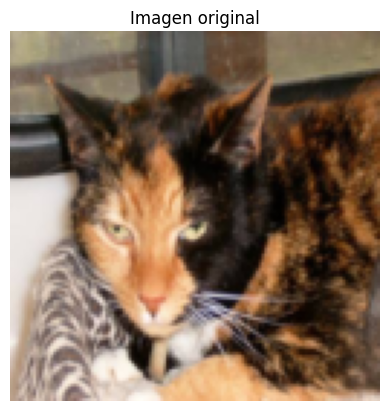

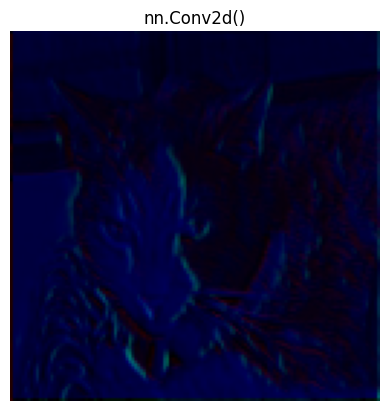

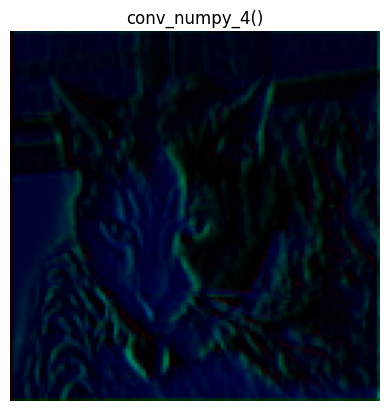

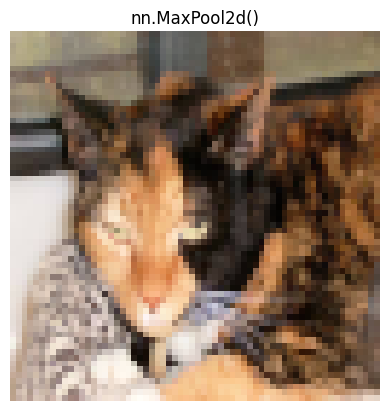

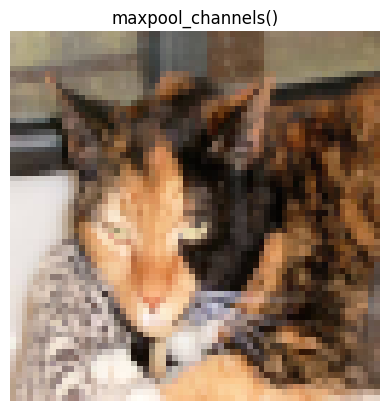

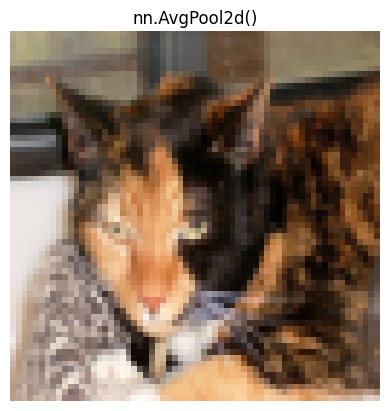

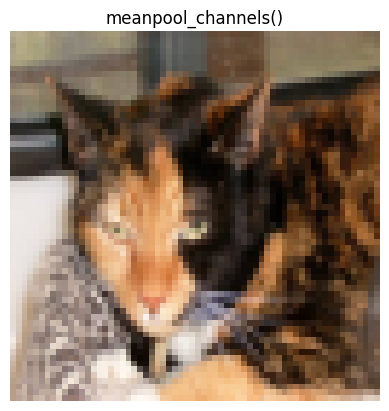

In [ ]:
test_image = test_loader.dataset[21][0]

model.compare_methods(test_image.to(DEVICE))

## **Parte II: Arquitecturas Encoder-Decoder (Teoría y Fórmulas)**

### 1. Arquitecturas Encoder-Decoder (Teoría y Fórmulas)

Un modelo **encoder-decoder** transforma una entrada $ \mathbf{x} \in \mathbb{R}^n $ en una salida $ \mathbf{y} \in \mathbb{R}^m $ mediante una representación latente $ \mathbf{z} \in \mathbb{R}^d $, donde normalmente $ d < n $.

#### 1.1 Encoder

El **encoder** convierte la entrada $ \mathbf{x} $ en una representación latente $ \mathbf{z} $:

$$
\mathbf{z} = f_{\text{enc}}(\mathbf{x}; \theta_e)
$$

- $ f_{\text{enc}} $: red neuronal (CNN, RNN, MLP, etc.)
- $ \theta_e $: parámetros del encoder
- $ \mathbf{z} $: vector latente comprimido

Si el encoder tiene múltiples capas:

$$
\mathbf{z} = f_L \circ f_{L-1} \circ \dots \circ f_1(\mathbf{x})
$$

En términos de dominio y codominio:

$$
f_{\text{enc}}: \mathbb{R}^n \rightarrow \mathbb{R}^d
$$

- $ \mathbf{x} \in \mathbb{R}^n $: entrada original
- $ \mathbf{z} = f_{\text{enc}}(\mathbf{x}) \in \mathbb{R}^d $: representación latente
- Típicamente $ d < n $ para compresión

#### 1.3. El modelo

El modelo completo es la composición de encoder y decoder:

$$
f_{\text{dec}} \circ f_{\text{enc}}: \mathbb{R}^n \rightarrow \mathbb{R}^m
$$

Es decir:

$$
\hat{\mathbf{y}} = f_{\text{dec}}(f_{\text{enc}}(\mathbf{x}))
$$

#### 1.2. Decoder

El **decoder** reconstruye o genera la salida a partir de $ \mathbf{z} $:

$$
\hat{\mathbf{y}} = f_{\text{dec}}(\mathbf{z}; \theta_d)
$$

- $ f_{\text{dec}} $: red decodificadora
- $ \theta_d $: parámetros del decoder
- $ \hat{\mathbf{y}} $: salida generada o reconstruida

Reconstruye o genera la salida desde el espacio latente:

$$
f_{\text{dec}}: \mathbb{R}^d \rightarrow \mathbb{R}^m
$$

- $ \mathbf{z} \in \mathbb{R}^d $: vector latente
- $ \hat{\mathbf{y}} = f_{\text{dec}}(\mathbf{z}) \in \mathbb{R}^m $: salida reconstruida o generada

#### 1.4. Función de Pérdida

El modelo se entrena minimizando la pérdida entre la salida generada $ \hat{\mathbf{y}} $ y la salida real $ \mathbf{y} $:

$$
\mathcal{L}(\mathbf{y}, \hat{\mathbf{y}}) = \mathcal{L}\left(\mathbf{y}, f_{\text{dec}}(f_{\text{enc}}(\mathbf{x}))\right)
$$

### Ejemplos comunes:

- **Reconstrucción (autoencoder):**

$$
\mathcal{L} = \|\mathbf{x} - f_{\text{dec}}(f_{\text{enc}}(\mathbf{x}))\|^2
$$

- **Segmentación (por píxel):**

$$
\mathcal{L} = \text{CrossEntropy}(\mathbf{y}, \hat{\mathbf{y}})
$$

- **Secuencia a secuencia (traducción):**

$$
\mathcal{L} = -\sum_{t=1}^T \log P(y_t \mid \mathbf{z}, y_{<t})
$$

#### 1.5. Optimización

El entrenamiento ajusta los parámetros del modelo $ \theta = \{\theta_e, \theta_d\} $ para minimizar la pérdida esperada:

$$
\theta^* = \arg \min_{\theta} \ \mathbb{E}_{(\mathbf{x}, \mathbf{y}) \sim \mathcal{D}} \left[ \mathcal{L}(\mathbf{y}, f_{\text{dec}}(f_{\text{enc}}(\mathbf{x}))) \right]
$$

Donde $ \mathcal{D} $ es el conjunto de datos de entrenamiento.


## **Parte III: Evaluación**

### **III-A. CNN**


#### 1. Considere la matriz:

  $X = \begin{bmatrix} 2 & 5 & 4 & 1 \\3 & 1 & 2 & 0 \\4 & 5 & 7 & 1 \\1 & 2 & 3 & 4 \end{bmatrix}$
  <br><br>

  **a)** Calcule la salida de una convolución de dimensión del kernel $2 \times 2$ sin padding y stride de $2$

  $K = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$
  <br><br>
  ***Respuesta:***
  <br>
  Sabemos que la convolución consiste en multiplicar cada elemento del kernel con su correspondiente en la matriz $X$, iniciando en el elemento $X_{0, 0}$ y desplazandonos una cantidad igual al stride, en este caso, igual a 2. Es por ello que, llamando a la matriz resultante $R$ y usando el símbolo $⊙$ para representar esta multiplicación entre elementos, se tienen los siguientes productos:

  ${R}_{0, 0} =
  \begin{equation}
  \begin{bmatrix} 2 & 5 \\ 3 & 1 \end{bmatrix} \odot
  \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
  =
  (2 \times 1) + (5 \times 0) + (3 \times 0) + (1 \times 1)
  =
  3
  \end{equation}$
  <br><br>
  ${R}_{0, 1} =
  \begin{equation}
  \begin{bmatrix} 4 & 1 \\ 2 & 0 \end{bmatrix} \odot
  \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
  =
  (4 \times 1) + (1 \times 0) + (2 \times 0) + (0 \times 1)
  =
  4
  \end{equation}$
  <br><br>
  ${R}_{1, 0} =
  \begin{equation}
  \begin{bmatrix} 4 & 5 \\ 1 & 2 \end{bmatrix} \odot
  \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
  =
  (4 \times 1) + (5 \times 0) + (1 \times 0) + (2 \times 1)
  =
  6
  \end{equation}$
  <br><br>
  ${R}_{1, 1} =
  \begin{equation}
  \begin{bmatrix} 7 & 1 \\ 3 & 4 \end{bmatrix} \odot
  \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
  =
  (7 \times 1) + (1 \times 0) + (3 \times 0) + (4 \times 1)
  =
  11
  \end{equation}$
  <br><br>
  Finalmente se tiene que la matriz $R$ es tal que:

  $R = \begin{bmatrix} 3 & 4 \\ 6 & 11 \end{bmatrix}$
  <br><br>

  **b)** Calcule la salida de una convolución de dimensión del kernel $2\times2$ padding $2$ y stride de $2$.

  $K = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$
  <br><br>
  ***Respuesta:***
  <br>
  Al tener un padding de $2$, debemos expandir la matriz original, podría decirse que agregándole un margen de dimensión 2, quedando como resultado:

  $X = \begin{bmatrix}
  0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
  0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
  0 & 0 & \textbf{2} & \textbf{5} & \textbf{4} & \textbf{1} & 0 & 0 \\
  0 & 0 & \textbf{3} & \textbf{1} & \textbf{2} & \textbf{0} & 0 & 0 \\
  0 & 0 & \textbf{4} & \textbf{5} & \textbf{7} & \textbf{1} & 0 & 0 \\
  0 & 0 & \textbf{1} & \textbf{2} & \textbf{3} & \textbf{4} & 0 & 0 \\
  0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
  0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \end{bmatrix}$
  <br><br>
  Es importante notar que al aplicar la multiplicación de la matriz $K$ con cualquiera de las submatrices de dimensión $2 \times 2$ pertenecientes al margen generado por el padding dará como resultado $0$, es por ello que, siendo la matriz resultante $R$ y sea $j∈[0, 3]$, las filas: $R_{0, j}$ y $R_{3, j}$ serán filas de $0's$, de igual forma ocurre con las columnas: $R_{j, 0}$ y $R_{j, 3}$, gracias a ello solo debemos calcular las siguientes posiciones de $R$:

  ${R}_{1, 1} =
  \begin{equation}
  \begin{bmatrix} 2 & 5 \\ 3 & 1 \end{bmatrix} \odot
  \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}
  =
  (2 \times 1) + (5 \times 0) + (3 \times 0) + (1 \times -1)
  =
  1
  \end{equation}$
  <br><br>
  ${R}_{1, 2} =
  \begin{equation}
  \begin{bmatrix} 4 & 1 \\ 2 & 0 \end{bmatrix} \odot
  \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}
  =
  (4 \times 1) + (1 \times 0) + (2 \times 0) + (0 \times -1)
  =
  4
  \end{equation}$
  <br><br>
  ${R}_{1, 0} =
  \begin{equation}
  \begin{bmatrix} 4 & 5 \\ 1 & 2 \end{bmatrix} \odot
  \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}
  =
  (4 \times 1) + (5 \times 0) + (1 \times 0) + (2 \times -1)
  =
  2
  \end{equation}$
  <br><br>
  ${R}_{1, 1} =
  \begin{equation}
  \begin{bmatrix} 7 & 1 \\ 3 & 4 \end{bmatrix} \odot
  \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}
  =
  (7 \times 1) + (1 \times 0) + (3 \times 0) + (4 \times -1)
  =
  3
  \end{equation}$
  <br>
  <br>
  Finalmente se tiene que la matriz $R$ es tal que:

  $R = \begin{bmatrix}
  0 & 0 & 0 & 0 \\
  0 & 1 & 4 & 0 \\
  0 & 2 & 3 & 0 \\
  0 & 0 & 0 & 0 \end{bmatrix}$


#### 2. ¿Cómo podemos determinar la dimensión de salida luego de aplicar la función de convolución?

Sea la matriz de entrada $M_{in}$ cuyas dimensiones son $H_{in} \times W_{in}$, al aplicarle la operación de convolución usando un kernel $K$ de dimensiones $H_k \times W_k$, usando un padding $P$ y un stride de $S$, la matriz resultante de la operación, a la que llamaremos $M_{out}$ tendrá dimensiones $H_{out} \times W_{out}$ que vienen dadas por:
<br><br>
$H_{out} = \lfloor{\frac{H_{in} - H_k + 2P}{S}}\rfloor + 1$
<br>
$W_{out} = \lfloor{\frac{W_{in} - W_k + 2P}{S}}\rfloor + 1$

#### 3. ¿Qué beneficios tiene el uso de CNNs sobre las redes completamente conectadas?

Las redes convolucionales poseen menos parámetros que las redes completamente conectadas, esto se debe a que los pesas aplicados se encuentran en el kernel y estos se aplican a toda la imagen en lugar de asignarle un peso a cada conexión.
Otro beneficio de las CNNs con respecto a las redes completamente conectadas es que las CNNs aprovechan la localidad espacial de los píxeles en una imagen, es decir, se aprovecha el hecho de que los píxeles cercanos suelen tener una correlación para aprender patrones y características, además, una vez aprendida una característica la red podrá reconocerla en cualquier lugar de la imagen.

### **III-B. CNN Segmentation**

En esta sección vamos a mejorar el rendimiento de la CNN planteada en el notebook: **[04_CNN_Segmentation](https://dl.ucv.ai/static_files/notebooks/04_CNN_Segmentation.ipynb)**

Como paso inicial, se tomaron las definiciones teóricas y las fórmulas y se agregaron en la Parte II de este notebook, a continuación se presentarán las celdas de código utilizadas, modificando el orden y organización de las mismas.

#### 1. Setup del dataset

Como paso inicial, se harán las descargas y los importes de las librerías necesarias.

In [9]:
!pip install torchinfo

In [27]:
import os
import torch
import keras
import random
import numbers
import requests
import numpy as np
import torchvision
import dataclasses
import tensorflow as tf
import torchvision.transforms as T

from os import path
from torch import nn
from keras import layers
from typing import Sequence
from torchinfo import summary
from PIL import Image, ImageOps
from keras.utils import load_img
from dataclasses import dataclass
from tensorflow import io as tf_io
from keras.models import load_model
from matplotlib import pyplot as plt
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from IPython.display import Image as p_Image
from IPython.display import display as p_display
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [11]:
# Convert a pytorch tensor into a PIL image
t2img = T.ToPILImage()
# Convert a PIL image into a pytorch tensor
img2t = T.ToTensor()

In [12]:
!!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

['--2025-07-27 05:23:18--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz',
 'Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2',
 'Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.',
 'HTTP request sent, awaiting response... 301 Moved Permanently',
 'Location: https://thor.robots.ox.ac.uk/pets/annotations.tar.gz [following]',
 '--2025-07-27 05:23:19--  https://thor.robots.ox.ac.uk/pets/annotations.tar.gz',
 'Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98',
 'Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.',
 'HTTP request sent, awaiting response... 200 OK',
 'Length: 19173078 (18M) [application/octet-stream]',
 'Saving to: ‘annotations.tar.gz’',
 '',
 '',
 'annotations.tar.gz    0%[                    ]       0  --.-KB/s               ',
 'annotations.tar.gz    0%[                    ]  71.77K   279KB/s               ',
 'annotations.tar.gz    0%[ 

In [13]:
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

#### 2. Exploración incial de los datos.

En esta sección van a definir y/o configurar los métodos necesarios para acceder al conjunto de datos, además de ello se mostrarán un par de ejemplos.

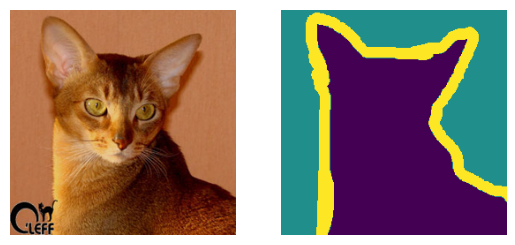

In [14]:
def get_unsplash_image():
    image_path = "stroller-unsplash.avif"

    if not os.path.exists(image_path):
        url = "https://images.unsplash.com/photo-1687017563985-a7193fcd7032"
        r = requests.get(url, allow_redirects=True)
        with open(image_path, 'wb') as fp:
            fp.write(r.content)
        # end with
    # end if

    image_256_path = "stroller-unsplash-256.png"

    if not os.path.exists(image_256_path):
        img = Image.open(image_path)
        img = img.resize((256, 256))
        img = img.convert("RGB")
        img.save(image_256_path)
    # end if

    img = Image.open(image_256_path)
    return img

def get_pet_cat_image_and_mask():
    img = Image.open(r"images/Abyssinian_169.jpg")
    img = img.convert("RGB").resize((256, 256))

    mask = Image.open(r"annotations/trimaps/Abyssinian_169.png")
    mask = mask.convert("L").resize((256, 256))
    mask = t2img((img2t(mask) * 255. - 1.) / 2.)
    return img, mask

img, mask = get_pet_cat_image_and_mask()

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.axis("off")

plt.show()

In [15]:
input_dir = "images/"
target_dir = "annotations/trimaps/"
img_size = (160, 160)
num_classes = 3
batch_size = 32

input_img_paths = sorted(
    [
        os.path.join(input_dir, fname)
        for fname in os.listdir(input_dir)
        if fname.endswith(".jpg")
    ]
)
target_img_paths = sorted(
    [
        os.path.join(target_dir, fname)
        for fname in os.listdir(target_dir)
        if fname.endswith(".png") and not fname.startswith(".")
    ]
)

print("Número de imágenes:", len(input_img_paths))

for input_path, target_path in zip(input_img_paths[:10], target_img_paths[:10]):
    print(input_path, "|", target_path)

Número de imágenes: 7390
images/Abyssinian_1.jpg | annotations/trimaps/Abyssinian_1.png
images/Abyssinian_10.jpg | annotations/trimaps/Abyssinian_10.png
images/Abyssinian_100.jpg | annotations/trimaps/Abyssinian_100.png
images/Abyssinian_101.jpg | annotations/trimaps/Abyssinian_101.png
images/Abyssinian_102.jpg | annotations/trimaps/Abyssinian_102.png
images/Abyssinian_103.jpg | annotations/trimaps/Abyssinian_103.png
images/Abyssinian_104.jpg | annotations/trimaps/Abyssinian_104.png
images/Abyssinian_105.jpg | annotations/trimaps/Abyssinian_105.png
images/Abyssinian_106.jpg | annotations/trimaps/Abyssinian_106.png
images/Abyssinian_107.jpg | annotations/trimaps/Abyssinian_107.png


A continuación se muestra la carga y el display de una imagen de prueba usando Keras.

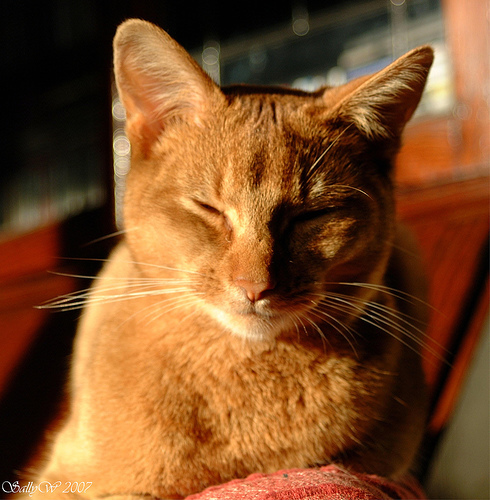

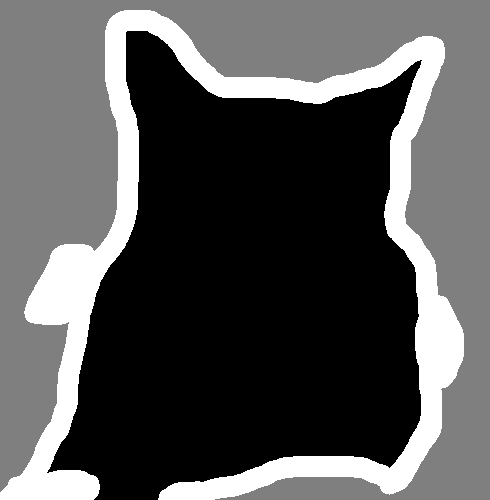

In [16]:
# Display input image #7
p_display(p_Image(filename=input_img_paths[15]))

# Display auto-contrast version of corresponding target (per-pixel categories)
img = ImageOps.autocontrast(load_img(target_img_paths[15]))
p_display(img)

#### 3. División del dataset en splits de entrenamiento y validación.

En la siguiente celda de código se definen las funciones necesarias para formatear los datos.

In [17]:
def get_dataset(
    batch_size,
    img_size,
    input_img_paths,
    target_img_paths,
    max_dataset_len=None,
):
    """Returns a TF Dataset."""

    def load_img_masks(input_img_path, target_img_path):
        input_img = tf_io.read_file(input_img_path)
        input_img = tf_io.decode_png(input_img, channels=3)
        input_img = tf_image.resize(input_img, img_size)
        input_img = tf_image.convert_image_dtype(input_img, "float32")

        target_img = tf_io.read_file(target_img_path)
        target_img = tf_io.decode_png(target_img, channels=1)
        target_img = tf_image.resize(target_img, img_size, method="nearest")
        target_img = tf_image.convert_image_dtype(target_img, "uint8")

        # Ground truth labels are 1, 2, 3. Subtract one to make them 0, 1, 2:
        target_img -= 1
        return input_img, target_img

    # For faster debugging, limit the size of data
    if max_dataset_len:
        input_img_paths = input_img_paths[:max_dataset_len]
        target_img_paths = target_img_paths[:max_dataset_len]
    dataset = tf_data.Dataset.from_tensor_slices((input_img_paths, target_img_paths))
    dataset = dataset.map(load_img_masks, num_parallel_calls=tf_data.AUTOTUNE)
    return dataset.batch(batch_size)

In [18]:
# Split our img paths into a training and a validation set
val_samples = 1000
random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_img_paths)
train_input_img_paths = input_img_paths[:-val_samples]
train_target_img_paths = target_img_paths[:-val_samples]
val_input_img_paths = input_img_paths[-val_samples:]
val_target_img_paths = target_img_paths[-val_samples:]

# Instantiate dataset for each split
# Limit input files in `max_dataset_len` for faster epoch training time.
# Remove the `max_dataset_len` arg when running with full dataset.
train_dataset = get_dataset(
    batch_size,
    img_size,
    train_input_img_paths,
    train_target_img_paths,
    # max_dataset_len=1000,
)
valid_dataset = get_dataset(
    batch_size, img_size, val_input_img_paths, val_target_img_paths
)

#### 4. Definición del modelo, entrenamiento y pruebas.

En la siguiente celda de código se define la estructura de nuestro modelo, para este, utilizamos una arquitectura U-Net Xception style

In [21]:
def get_improved_model(img_size, num_classes, drop_rate=0.15):
  inputs = keras.Input(shape=img_size + (3,))

  ### [First half of the network: downsampling inputs] ###

  # Lista para almacenar las salidas de cada nivel del encoder para las skip connections
  skip_connections = []

  # Entry block
  x = layers.Conv2D(32, 3, strides=2, padding="same")(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.Activation("relu")(x)
  skip_connections.append(x) # Guarda la salida del primer bloque

  # Blocks 1, 2, 3 (Encoder)
  for filters in [64, 128, 256]:
      x = layers.Activation("relu")(x)
      x = layers.SeparableConv2D(filters, 3, padding="same")(x)
      x = layers.BatchNormalization()(x)
      x = layers.Dropout(drop_rate)(x)

      x = layers.Activation("relu")(x)
      x = layers.SeparableConv2D(filters, 3, padding="same")(x)
      x = layers.BatchNormalization()(x)
      x = layers.Dropout(drop_rate)(x)

      x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
      skip_connections.append(x) # Guarda la salida de cada nivel del encoder

  bottleneck = skip_connections.pop() # El último elemento no es para concatenar directamente con un nivel de upsampling

  ### [Second half of the network: upsampling inputs] ###
  x = bottleneck # El decoder empieza desde el cuello de botella

  # Blocks (Decoder)
  for filters in [256, 128, 64]:
    x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(drop_rate)(x)

    skip_feature = skip_connections.pop() # Obtiene la conexión de salto correspondiente

    x = layers.concatenate([x, skip_feature]) # Concatena las características

    # Bloques convolucionales después de la concatenación
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(drop_rate)(x)

    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(drop_rate)(x)

  x = layers.Activation("relu")(x)
  x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Dropout(drop_rate)(x)

  x = layers.Activation("relu")(x)
  x = layers.SeparableConv2D(32, 3, padding="same")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Dropout(drop_rate)(x)

  # Add a per-pixel classification layer
  outputs = layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)

  # Define the model
  model = keras.Model(inputs, outputs)
  return model

In [22]:
# Build model
model = get_improved_model(img_size, num_classes)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 80, 80,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 80, 80,    │          0 │ activation_18[0]… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_13 │ (None, 80, 80,    │      2,400 │ activation_19[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 80, 80,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 80, 80,    │          0 │ dropout[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_14 │ (None, 80, 80,    │      4,736 │ activation_20[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 80, 80,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 40, 40,    │          0 │ dropout_1[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 40, 40,    │          0 │ max_pooling2d_3[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_15 │ (None, 40, 40,    │      8,896 │ activation_21[0]… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 40, 40,    │          0 │ batch_normalizat

 Total params: 1,351,811 (5.16 MB)

 Trainable params: 1,347,139 (5.14 MB)

 Non-trainable params: 4,672 (18.25 KB)

In [24]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    mode='min',
    min_lr=1e-6
)

In [26]:
def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

Hablar de las modificaciones hechas y pasar al entrenamiento del modelo:

In [ ]:
# Configure the model for training.
# We use the "sparse" version of categorical_crossentropy
# because our target data is integers.

model_name = "models/UCV-1000.keras"

model.compile(
    optimizer=keras.optimizers.Adam(1e-4), loss="sparse_categorical_crossentropy",
    metrics=[iou_metric, dice_coefficient]
    lr_scheduler
)

callbacks = [
    keras.callbacks.ModelCheckpoint(model_name, save_best_only=True),
    keras.callbacks.TensorBoard('./logs', update_freq=1)
]

# Train the model, doing validation at the end of each epoch.
epochs = 50
history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=valid_dataset,
    callbacks=callbacks,
    verbose=2,
)

Resultados del entrenamiento:

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['val_dice_coefficient'], label='Validation Dice')
plt.plot(history.history['val_iou_metric'], label='Validation IoU')
plt.title('Custom metrics')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

Pruebas finales

In [ ]:
model = None

if model is None:
  # Load the model
  model = load_model(model_name)

val_dataset = get_dataset(
    batch_size, img_size, val_input_img_paths, val_target_img_paths
)
val_preds = model.predict(val_dataset)


def display_mask(i):
    """Quick utility to display a model's prediction."""
    mask = np.argmax(val_preds[i], axis=-1)
    mask = np.expand_dims(mask, axis=-1)
    img = ImageOps.autocontrast(keras.utils.array_to_img(mask))
    display(img)


# Display results for validation image #10
i = 10

# Display input image
display(Image(filename=val_input_img_paths[i]))

# Display ground-truth target mask
img = ImageOps.autocontrast(load_img(val_target_img_paths[i]))
display(img)

# Display mask predicted by our model
display_mask(i)  # Note that the model only sees inputs at 150x150.